# Notebook 1: Data Forensics and Cleaning
The Goal: Prove that you understood the raw datasets, properly defined numerical vs. categorical boundaries, and successfully neutralized the "System Ghosts" without destroying the underlying variance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load raw and clean master data for categorical shift
raw_master = pd.read_parquet('../data/bronze/outlet_master.parquet')
clean_master = pd.read_parquet('../data/silver/outlet_master_clean.parquet')

# Load raw and clean transactions
raw_trans = pd.read_parquet('../data/bronze/transactions_history.parquet')
clean_trans = pd.read_parquet('../data/silver/transactions_clean.parquet')


### Plot 1: The Missingness Matrix (Pre-Cleaning)

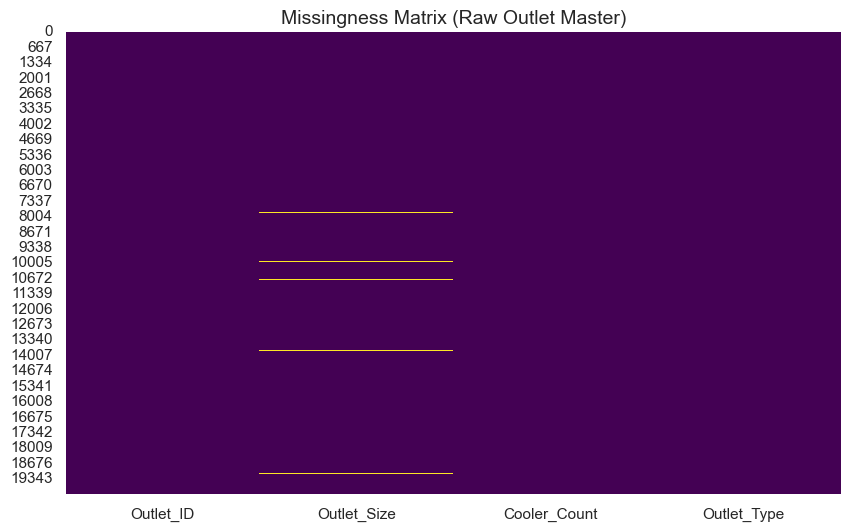

In [2]:
plt.figure(figsize=(10, 6))
sns.heatmap(raw_master.isnull(), cbar=False, cmap='viridis')
plt.title("Missingness Matrix (Raw Outlet Master)", fontsize=14)
plt.show()


### Plot 2: Categorical Distribution Shift (Master Data Decay)

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_97098/1550394250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Outlet_Size', data=raw_master, ax=axes[0], order=raw_master['Outlet_Size'].value_counts().index, palette='Blues_d')
/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_97098/1550394250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Dynamic_Tier', data=clean_master, ax=axes[1], order=clean_master['Dynamic_Tier'].value_counts().index, palette='Greens_d')


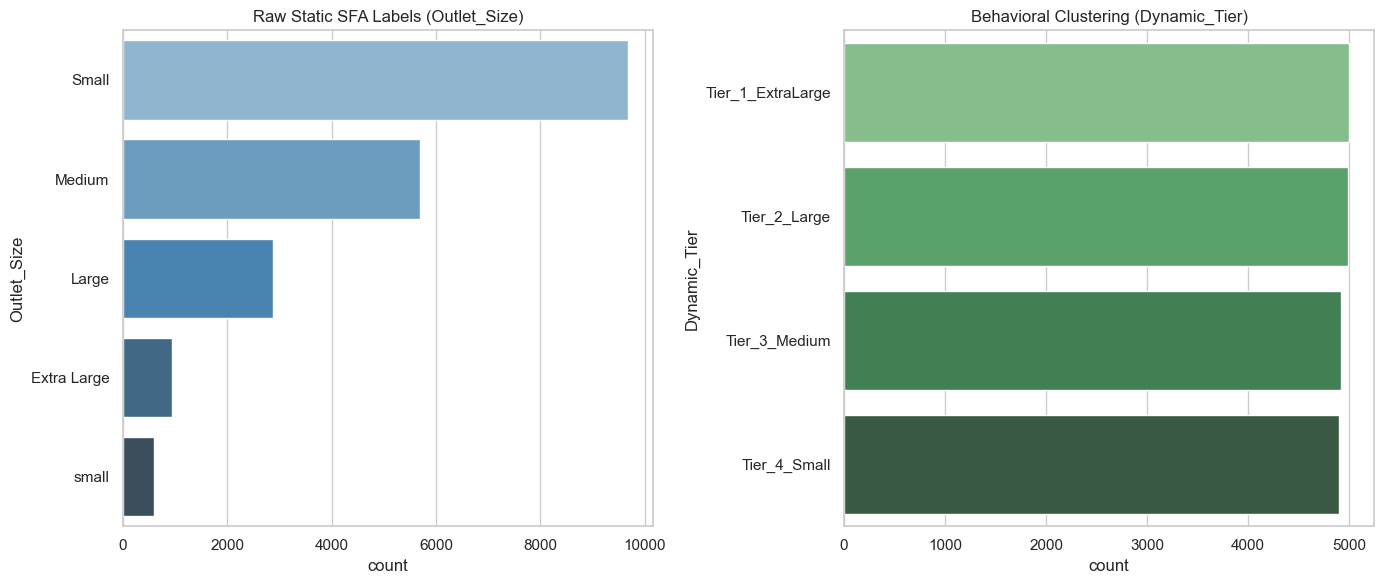

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(y='Outlet_Size', data=raw_master, ax=axes[0], order=raw_master['Outlet_Size'].value_counts().index, palette='Blues_d')
axes[0].set_title("Raw Static SFA Labels (Outlet_Size)")

sns.countplot(y='Dynamic_Tier', data=clean_master, ax=axes[1], order=clean_master['Dynamic_Tier'].value_counts().index, palette='Greens_d')
axes[1].set_title("Behavioral Clustering (Dynamic_Tier)")
plt.tight_layout()
plt.show()


### Plot 3: The Ghost Exorcism (Numerical Distribution)

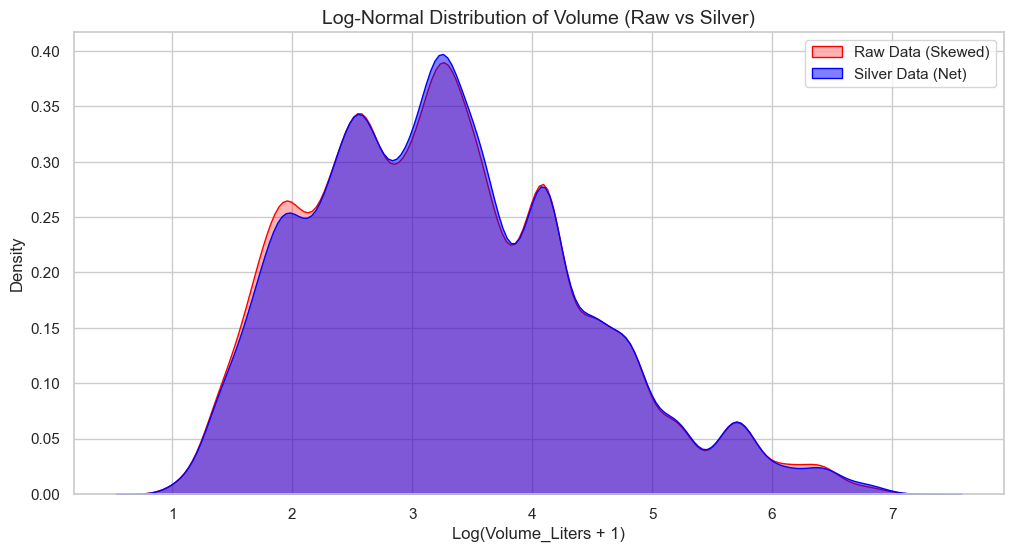

In [4]:
plt.figure(figsize=(12, 6))
sns.kdeplot(np.log1p(raw_trans[raw_trans['Volume_Liters']>0]['Volume_Liters'].sample(50000, random_state=42)), label='Raw Data (Skewed)', fill=True, color='red', alpha=0.3)
sns.kdeplot(np.log1p(clean_trans[clean_trans['Volume_Liters']>0]['Volume_Liters'].sample(50000, random_state=42)), label='Silver Data (Net)', fill=True, color='blue', alpha=0.5)
plt.title("Log-Normal Distribution of Volume (Raw vs Silver)", fontsize=14)
plt.xlabel("Log(Volume_Liters + 1)")
plt.legend()
plt.show()
